## Data Science Project

## Turbine Health Monitoring and Failure Forecasting

In [15]:
# Step 1

# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

In [16]:
# Load Dataset

df = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Turbine Health Monitoring/wind turbine data set.csv')

In [17]:
print("Shape:", df.shape)

Shape: (9000, 13)


In [18]:
print(df.head())

  TurbineID  WindSpeed  RotorSpeed  BladeAngle  GearboxTemp  GeneratorTemp  \
0       T56       23.9        12.3          34           98             77   
1       T46       12.6        17.6          27           84             86   
2       T47       22.4        18.0          30           94             86   
3       T79       12.9        18.0          27           71             88   
4       T16        8.6        13.8          27           79             93   

   Vibration  PowerOutput  Humidity  AmbientTemperature  \
0       0.98          936        65                  27   
1       0.70         1517        74                  33   
2       0.76         1460        73                  16   
3       0.74         1134        68                  32   
4       1.33         1485        79                  21   

   TimeSinceLastMaintenance  Failure  FaultType  
0                       143        0        NaN  
1                       221        0        NaN  
2                       15

In [19]:
print("\nData Types:\n", df.dtypes)


Data Types:
 TurbineID                    object
WindSpeed                   float64
RotorSpeed                  float64
BladeAngle                    int64
GearboxTemp                   int64
GeneratorTemp                 int64
Vibration                   float64
PowerOutput                   int64
Humidity                      int64
AmbientTemperature            int64
TimeSinceLastMaintenance      int64
Failure                       int64
FaultType                    object
dtype: object


In [20]:
# Step 2

# Data Cleaning

# check missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 TurbineID                      0
WindSpeed                      0
RotorSpeed                     0
BladeAngle                     0
GearboxTemp                    0
GeneratorTemp                  0
Vibration                      0
PowerOutput                    0
Humidity                       0
AmbientTemperature             0
TimeSinceLastMaintenance       0
Failure                        0
FaultType                   7848
dtype: int64


In [21]:
# Check Duplicates
print("\nDuplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicates: 0


In [22]:
# Drop TurbineID

df.drop(columns=["TurbineID"], inplace=True)

In [23]:
# Fill FaultType NaN with "None" for multi-class task

df["FaultType"] = df["FaultType"].fillna("None")
print("\nCleaned Shape:", df.shape)


Cleaned Shape: (9000, 12)


In [24]:
print("\nFaultType distribution:\n", df["FaultType"].value_counts())


FaultType distribution:
 FaultType
None         7848
Gearbox       586
Blades        314
Generator     252
Name: count, dtype: int64


In [25]:
# Step 3

# Exploratory Data Analysis
# Descriptive Statistics

print("\nDescriptive Statistics:\n", df.describe().round(2))


Descriptive Statistics:
        WindSpeed  RotorSpeed  BladeAngle  GearboxTemp  GeneratorTemp  \
count    9000.00     9000.00     9000.00      9000.00        9000.00   
mean       14.97       15.01       30.02        85.07          85.12   
std         5.79        2.88        8.69         8.65           5.78   
min         5.00       10.00       15.00        70.00          75.00   
25%         9.90       12.50       23.00        78.00          80.00   
50%        14.90       15.10       30.00        85.00          85.00   
75%        20.00       17.50       38.00        93.00          90.00   
max        25.00       20.00       45.00       100.00          95.00   

       Vibration  PowerOutput  Humidity  AmbientTemperature  \
count    9000.00      9000.00   9000.00             9000.00   
mean        1.00      1447.85     70.03               24.96   
std         0.29       319.90      5.74                5.76   
min         0.50       900.00     60.00               15.00   
25%       

In [26]:
# Failure Rate
failure_rate = df["Failure"].mean() * 100
print(f"\nOverall Failure Rate: {failure_rate:.2f}%")


Overall Failure Rate: 12.80%


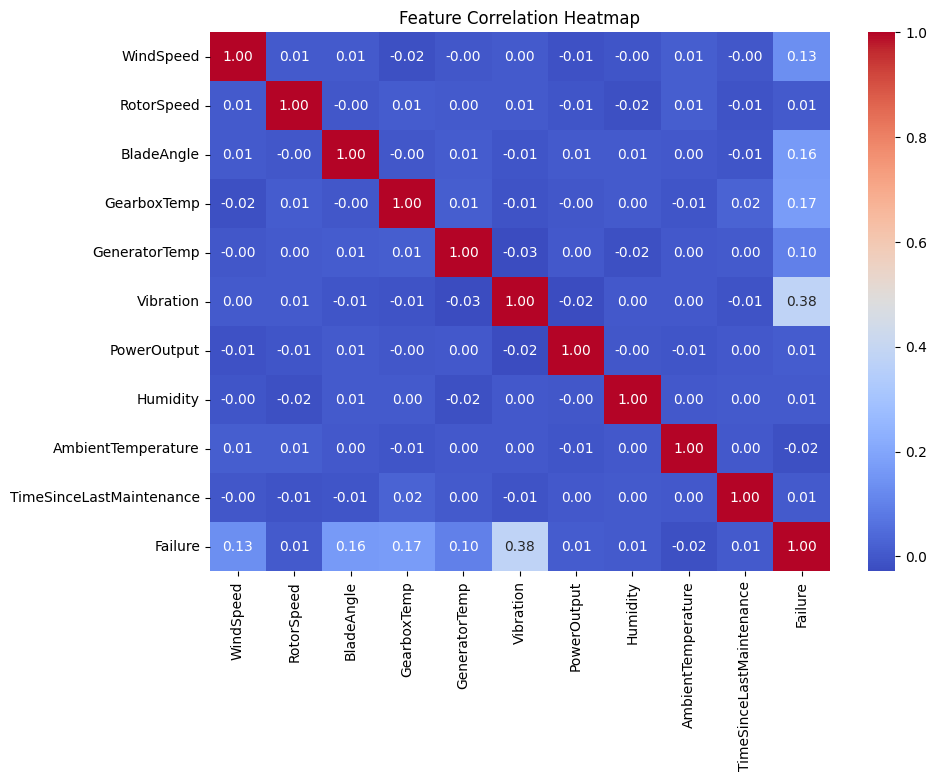

<Figure size 640x480 with 0 Axes>

In [27]:
# Correlation heatmap

plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()
plt.tight_layout()


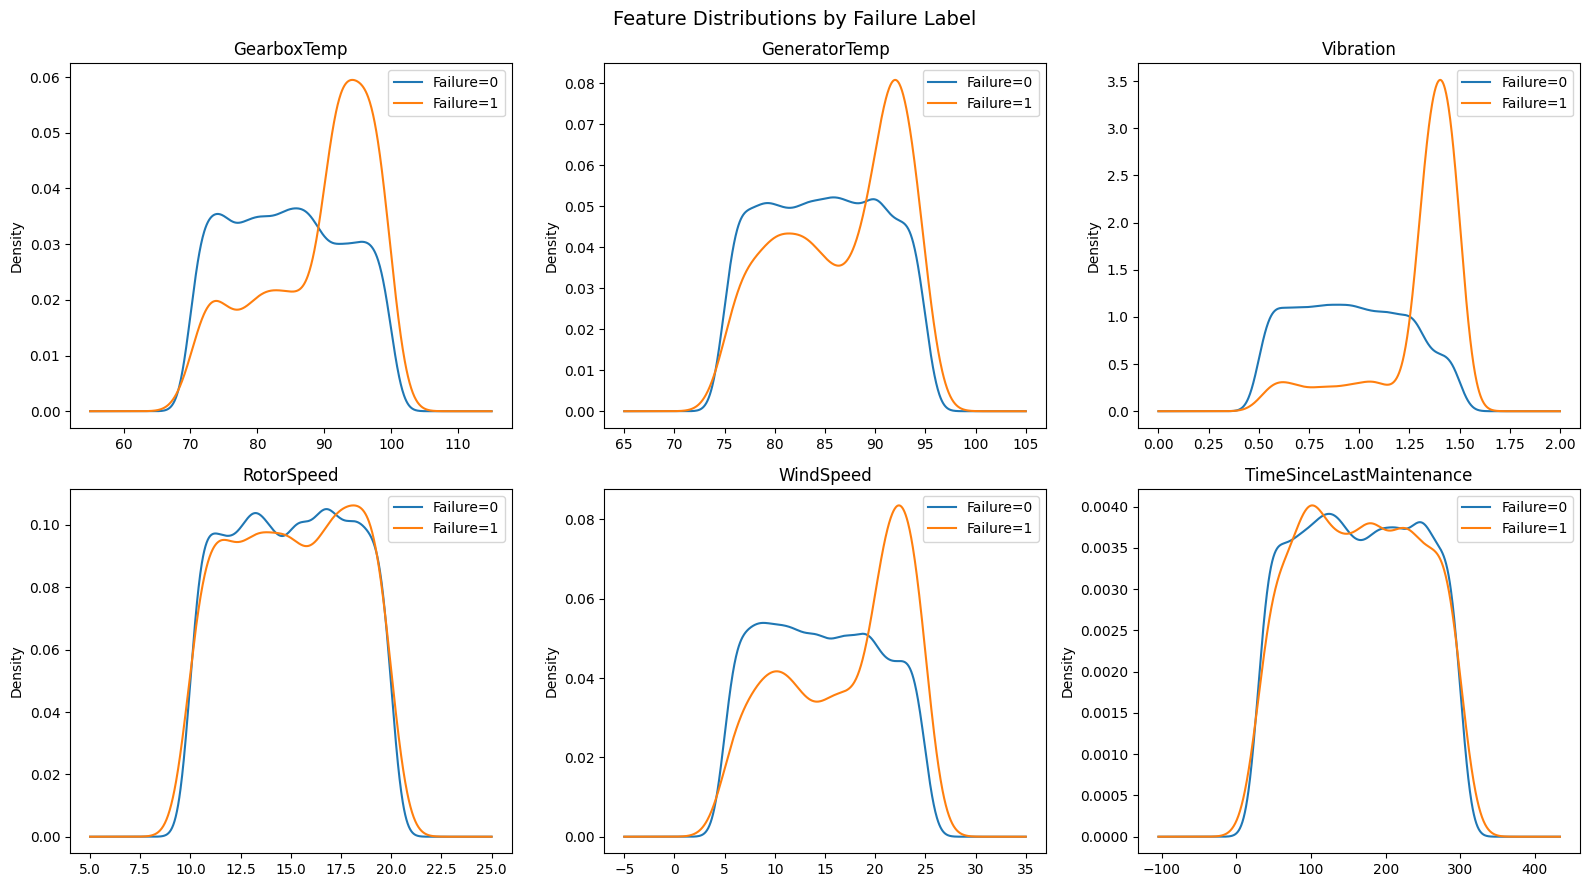

In [28]:
# Distribution of numeric features split by failure

features = ["GearboxTemp", "GeneratorTemp", "Vibration", "RotorSpeed",
            "WindSpeed", "TimeSinceLastMaintenance"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flatten(), features):
    for label, grp in df.groupby("Failure"):
        grp[feat].plot.kde(ax=ax, label=f"Failure={label}")
    ax.set_title(feat)
    ax.legend()
plt.suptitle("Feature Distributions by Failure Label", fontsize=14)
plt.tight_layout()

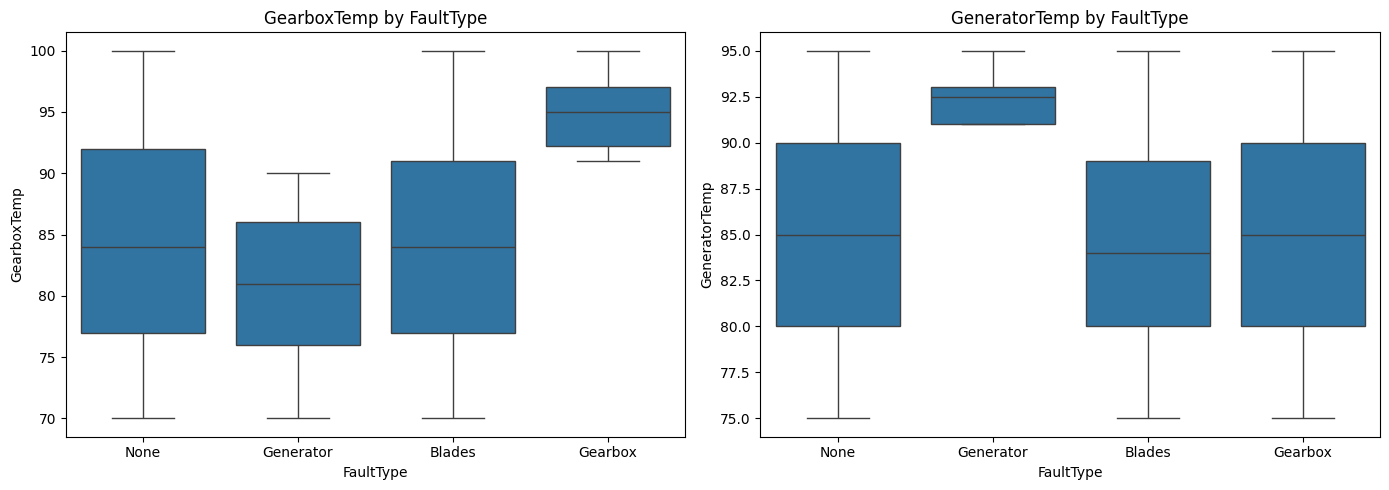

In [29]:
# Box plots for temperatures vs fault type

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="FaultType", y="GearboxTemp", ax=axes[0])
axes[0].set_title("GearboxTemp by FaultType")
sns.boxplot(data=df, x="FaultType", y="GeneratorTemp", ax=axes[1])
axes[1].set_title("GeneratorTemp by FaultType")
plt.tight_layout()

In [30]:
# Step 4 

# Feature Engineering
# Temperature Stress Index
df["TempStress"] = df["GearboxTemp"] + df["GeneratorTemp"] - 2 * df["AmbientTemperature"]

# Power efficiency ratio 
df["PowerEfficiency"] = df["PowerOutput"] / (df["WindSpeed"] + 1e-5)
# --> 1e-5 is used to avoid division by zero

# Temperature Difference
df["TempDiff"] = df["GearboxTemp"] - df["GeneratorTemp"]

# Average Temperature
df["AvgTemp"] = (df["GearboxTemp"] + df["GeneratorTemp"]) / 2

# Vibration Maintenance 
df["Vibration_Maintenance"] = df["Vibration"] * df["TimeSinceLastMaintenance"]



In [31]:
df

,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType,TempStress,PowerEfficiency,TempDiff,AvgTemp,Vibration_Maintenance
0,23.9,12.3,34,98,77,0.98,936,65,27,143,0,None,121,39.163164,21,87.5,140.14
1,12.6,17.6,27,84,86,0.70,1517,74,33,221,0,None,104,120.396730,-2,85.0,154.70
2,22.4,18.0,30,94,86,0.76,1460,73,16,151,0,None,148,65.178542,8,90.0,114.76
3,12.9,18.0,27,71,88,0.74,1134,68,32,169,0,None,95,87.906909,-17,79.5,125.06
4,8.6,13.8,27,79,93,1.33,1485,79,21,180,1,Generator,130,172.674218,-14,86.0,239.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,19.3,13.0,20,77,89,1.26,1409,62,30,267,0,None,106,73.005144,-12,83.0,336.42
8996,13.9,16.0,34,95,84,1.31,1428,64,21,124,1,Gearbox,137,102.733739,11,89.5,162.44
8997,10.7,18.1,32,98,92,1.01,1230,65,34,115,0,None,122,114.953164,6,95.0,116.15
8998,15.5,10.6,42,91,92,0.91,1305,66,25,213,0,None,133,84.193494,-1,91.5,193.83


In [32]:
print("\n Feature Engineering:", df.shape)


 Feature Engineering: (9000, 17)


In [33]:
# Step 5 

# Prepare features for modelling
FEATURE_COLS = [c for c in df.columns if c not in ["Failure", "FaultType"]]
X = df[FEATURE_COLS]
y_binary = df["Failure"]
y_multi = df["FaultType"]

In [34]:
# Label-encode
le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)
print("\nFaultType classes:", le.classes_) 

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS)


FaultType classes: ['Blades' 'Gearbox' 'Generator' 'None']


In [35]:
# Step 6

# Train Test Split

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)


In [36]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f"\nAfter SMOTE — Train size: {X_train.shape[0]}, "
      f"Positive class: {y_train.sum()} ({y_train.mean()*100:.1f}%)")


After SMOTE — Train size: 12556, Positive class: 6278 (50.0%)


In [37]:
# Step 7

# Train Classifiers (Failure Predictions)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42,
                                         use_label_encoder=False, eval_metric="logloss",
                                         n_jobs=-1),
}

In [38]:
results = {}

print("\n--- Binary Classification Results ---\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "AUC": auc,
        "F1-Failure": report["1"]["f1-score"],
        "Recall-Failure": report["1"]["recall"],
        "Precision-Failure": report["1"]["precision"],
    }
    print(f"[{name}]  AUC={auc:.3f}  F1(failure)={report['1']['f1-score']:.3f}  "
          f"Recall(failure)={report['1']['recall']:.3f}")



--- Binary Classification Results ---

[Logistic Regression]  AUC=0.890  F1(failure)=0.506  Recall(failure)=0.774
[Decision Tree]  AUC=0.999  F1(failure)=0.991  Recall(failure)=1.000
[Random Forest]  AUC=1.000  F1(failure)=0.998  Recall(failure)=1.000
[Gradient Boosting]  AUC=1.000  F1(failure)=1.000  Recall(failure)=1.000
[XGBoost]  AUC=1.000  F1(failure)=0.994  Recall(failure)=1.000


In [39]:
# Summary table
results_df = pd.DataFrame(results).T.sort_values("AUC", ascending=False)
print("\nRanked Summary:\n", results_df.round(3))


Ranked Summary:
                        AUC  F1-Failure  Recall-Failure  Precision-Failure
Random Forest        1.000       0.998           1.000              0.996
Gradient Boosting    1.000       1.000           1.000              1.000
XGBoost              1.000       0.994           1.000              0.987
Decision Tree        0.999       0.991           1.000              0.983
Logistic Regression  0.890       0.506           0.774              0.376


In [40]:
# Step 8 
# XGBoost

best_model_name = "XGBoost"
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print(f"\n--- Detailed Report: {best_model_name} ---\n")
print(classification_report(y_test, y_pred_best, target_names=["No Failure", "Failure"]))


--- Detailed Report: XGBoost ---

              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1570
     Failure       0.99      1.00      0.99       230

    accuracy                           1.00      1800
   macro avg       0.99      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



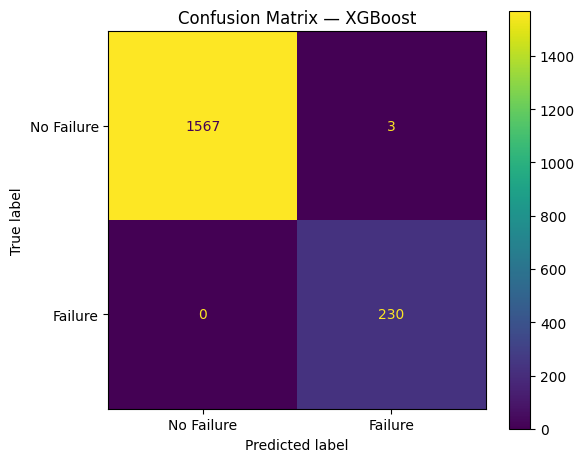

In [41]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, display_labels=["No Failure", "Failure"], ax=ax
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()

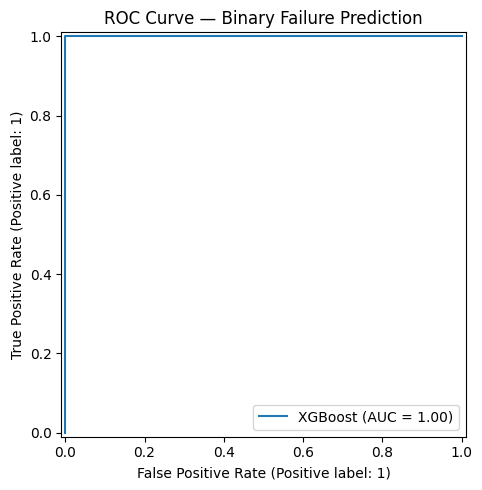

In [42]:
# ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=ax, name=best_model_name)
plt.title("ROC Curve — Binary Failure Prediction")
plt.tight_layout()

In [43]:
# Step 9 

# Cross Validation 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_scaled, y_binary,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"\nCross-Val AUC ({best_model_name}): "
      f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# If this is much lower than Step 7 AUC → model is overfitting. Tune regularization.


Cross-Val AUC (XGBoost): 1.000 ± 0.000


In [44]:
# Step 10

# FaultType Prediction

failure_mask = df["Failure"] == 1
X_fault = X_scaled[failure_mask.values]
y_fault = y_multi_enc[failure_mask.values]

print(f"\nFault type dataset size: {X_fault.shape[0]} rows")
print("Class distribution:", dict(zip(le.classes_, np.bincount(y_fault))))


Fault type dataset size: 1152 rows
Class distribution: {'Blades': np.int64(314), 'Gearbox': np.int64(586), 'Generator': np.int64(252)}


In [45]:
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_fault, y_fault, test_size=0.2, random_state=42, stratify=y_fault
)

In [46]:
xgb_multi = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    use_label_encoder=False, eval_metric="mlogloss",
    random_state=42, n_jobs=-1
)
xgb_multi.fit(X_f_train, y_f_train)
y_f_pred = xgb_multi.predict(X_f_test)


In [47]:
print("\n Multiclass FaultType Report \n")

# Filter le.classes_ to only include fault types
fault_classes = [c for c in le.classes_ if c != "None"]

# Re-encode only the failure subset
le_fault = LabelEncoder()
y_fault_labels = le_fault.fit_transform(y_multi[failure_mask.values])
xgb_multi2 = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                           use_label_encoder=False, eval_metric="mlogloss",
                           random_state=42, n_jobs=-1)

X_f2_train, X_f2_test, y_f2_train, y_f2_test = train_test_split(
    X_fault, y_fault_labels, test_size=0.2, random_state=42, stratify=y_fault_labels
)
xgb_multi2.fit(X_f2_train, y_f2_train)
y_f2_pred = xgb_multi2.predict(X_f2_test)

print(classification_report(y_f2_test, y_f2_pred, target_names=le_fault.classes_))


 Multiclass FaultType Report 

              precision    recall  f1-score   support

      Blades       1.00      1.00      1.00        63
     Gearbox       1.00      1.00      1.00       117
   Generator       1.00      1.00      1.00        51

    accuracy                           1.00       231
   macro avg       1.00      1.00      1.00       231
weighted avg       1.00      1.00      1.00       231



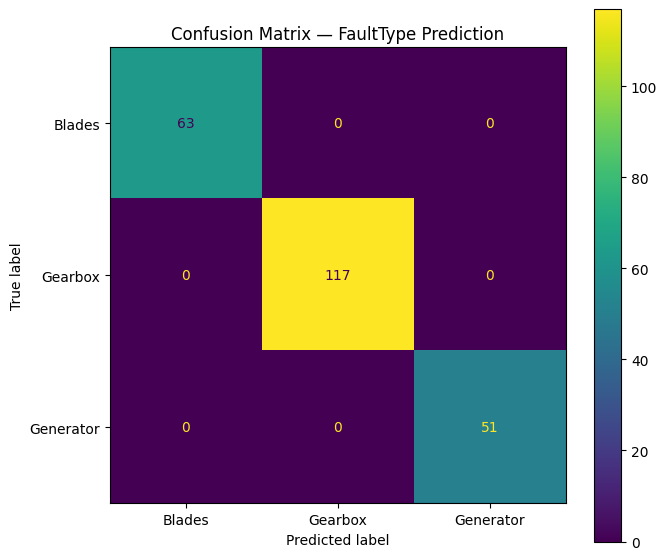

In [48]:
# Confusion matrix for fault types
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_f2_test, y_f2_pred, display_labels=le_fault.classes_, ax=ax
)
plt.title("Confusion Matrix — FaultType Prediction")
plt.tight_layout()


Top 5 Features:
 Vibration      0.382748
BladeAngle     0.162204
WindSpeed      0.084464
AvgTemp        0.065299
GearboxTemp    0.060751
dtype: float64


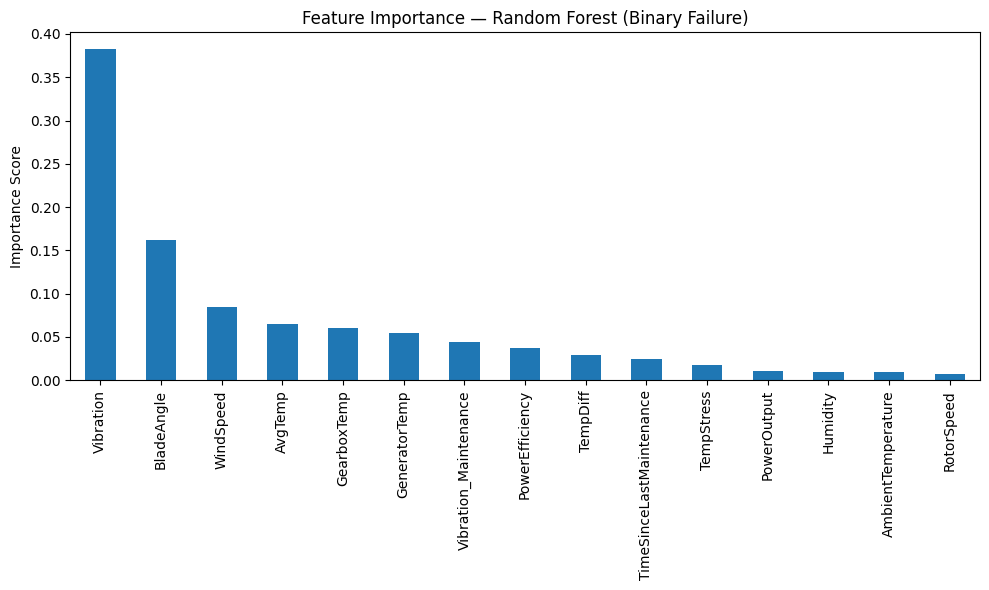

In [49]:
# Step 11

# Feature Importance

rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind="bar")
plt.title("Feature Importance — Random Forest (Binary Failure)")
plt.ylabel("Importance Score")
plt.tight_layout()

print("\nTop 5 Features:\n", importances.head())

In [50]:
# Step 12

# SHAP Explainability
# SHAP shows *why* the model made each prediction — useful for maintenance teams.

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

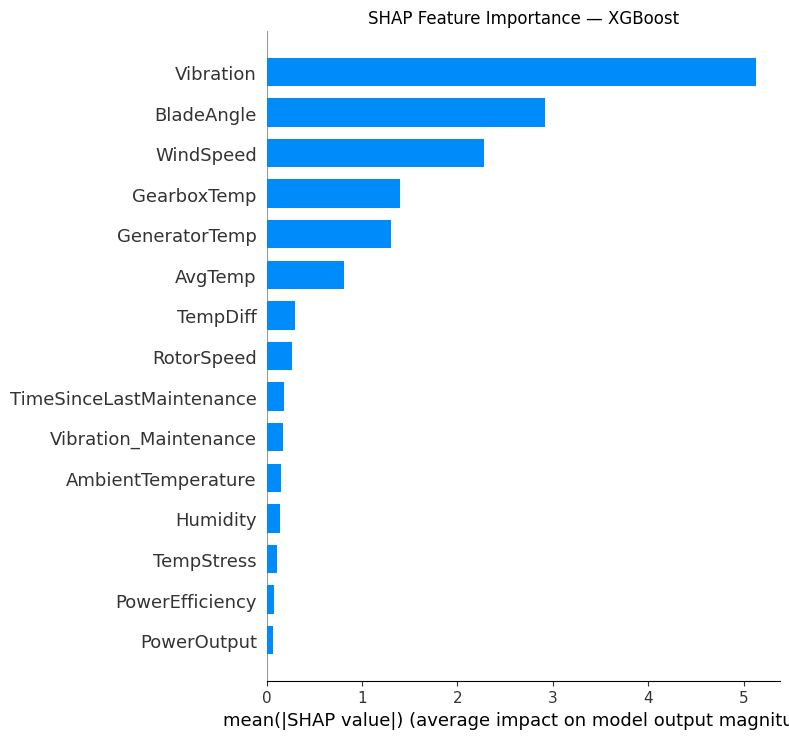

In [51]:
# Summary plot (global feature importance + direction of effect)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()

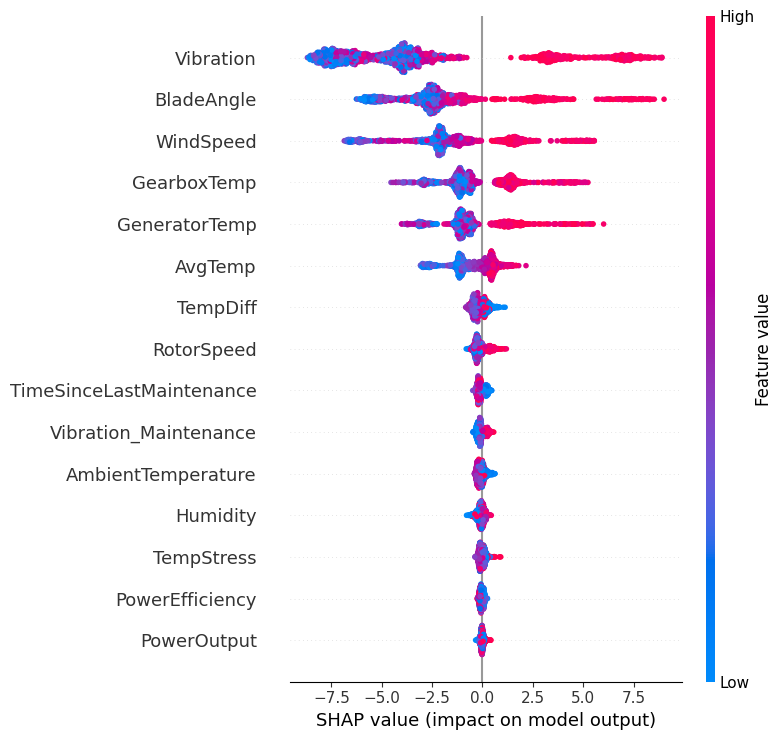

In [52]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()

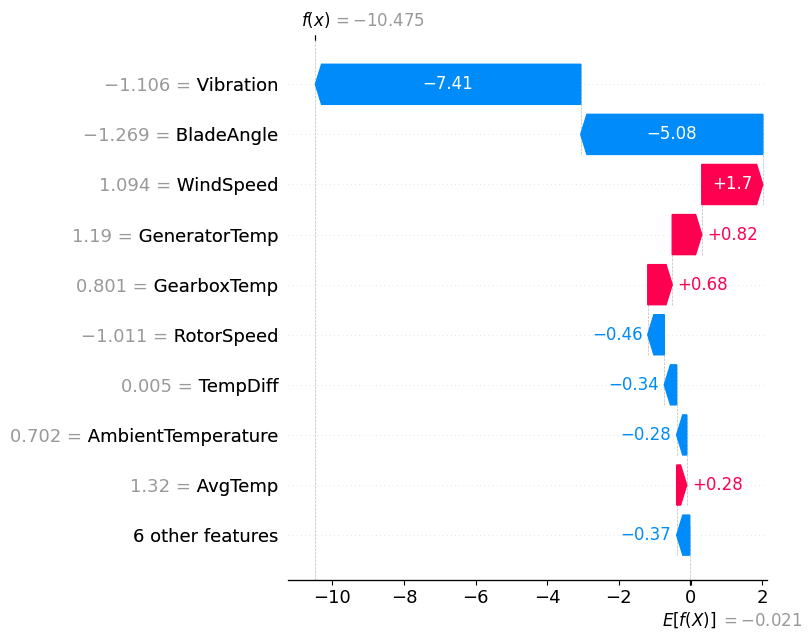

In [53]:
# Single prediction explanation (first test sample)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=FEATURE_COLS,
    ),
    show=False
)
plt.tight_layout()
plt.show()

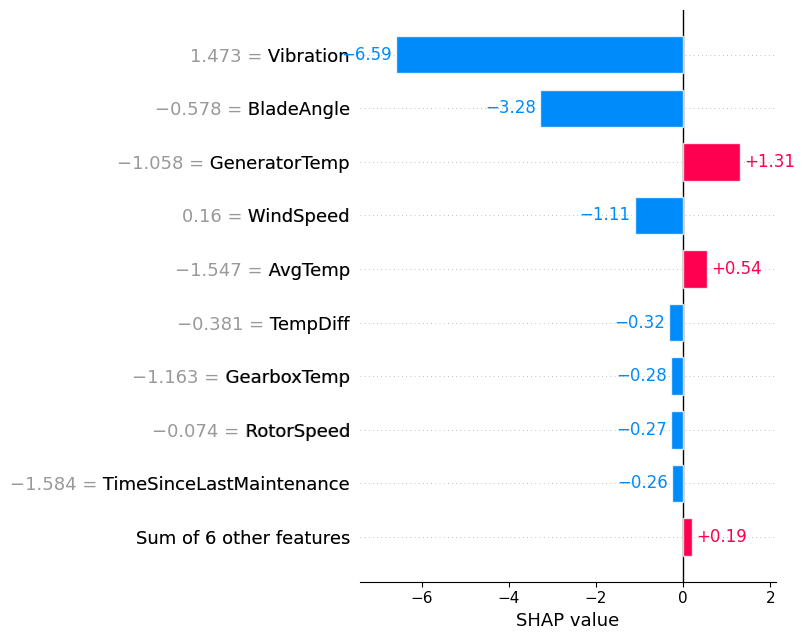

In [54]:
# Single prediction explanation (first test sample)
shap.plots.bar(
    shap.Explanation(
        values=shap_values[3],
        base_values=explainer.expected_value,
        data=X_test.iloc[5],
        feature_names=FEATURE_COLS,
    ),
    show=False
)
plt.tight_layout()
plt.show()

Prediction: Failure
Failure Probability: 99.9%


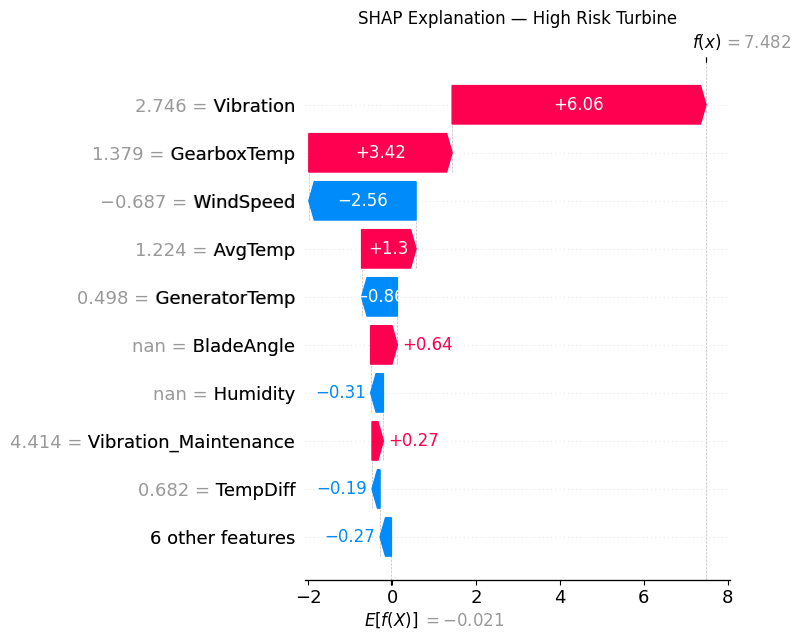

In [57]:
# Define a custom high-risk turbine reading
sample = pd.DataFrame([{
    "GearboxTemp": 97,
    "GeneratorTemp": 88,
    "Vibration": 1.8,
    "RotorSpeed": 13,
    "WindSpeed": 11,
    "PowerOutput": 1200,
    "AmbientTemperature": 22,
    "TimeSinceLastMaintenance": 320,
    "HydraulicPressure": 195,
    "BladePitch": 15,
    "NacelleOrientation": 180,
    "TempStress": 95 + 88 - 2 * 22,
    "PowerEfficiency": 1200 / (11 + 1e-5),
    "TempDiff": 95 - 88,
    "AvgTemp": (95 + 88) / 2,
    "Vibration_Maintenance": 1.8 * 320
}], columns=FEATURE_COLS)

sample_scaled = pd.DataFrame(scaler.transform(sample), columns=FEATURE_COLS)

# Predict
pred = best_model.predict(sample_scaled)[0]
prob = best_model.predict_proba(sample_scaled)[0][1]
print(f"Prediction: {'Failure' if pred == 1 else 'Healthy'}")
print(f"Failure Probability: {prob*100:.1f}%")

# Explain
shap_sample = explainer.shap_values(sample_scaled)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_sample[0],
        base_values=explainer.expected_value,
        data=sample_scaled.iloc[0],
        feature_names=FEATURE_COLS,
    ),
    show=False
)
plt.title("SHAP Explanation — High Risk Turbine")
plt.tight_layout()
plt.show()